# Parkshare — Étude de marché par la donnée

**Objectif** : Identifier les zones géographiques à fort potentiel commercial pour Parkshare,
plateforme de partage de places de stationnement en copropriété.

## Sources de données

| Source | Donnée | URL |
|--------|--------|-----|
| RNCC / data.gouv.fr | Registre National des Copropriétés (626 000 copropriétés) | https://www.data.gouv.fr/fr/datasets/registre-national-dimmatriculation-des-coproprietes |
| API Géo / data.gouv.fr | Population, surface et coordonnées GPS des communes | https://geo.api.gouv.fr/communes |

> **Note** : Les sources INSEE (RP2020 Logements et Mobilité) ont été écartées en raison
> d'une indisponibilité des serveurs au moment de la collecte. Les données de l'API Géo
> (population, densité) et du RNCC (lots habitation, lots parking) couvrent l'ensemble
> des indicateurs nécessaires au scoring.

## Pipeline

```
Section 1 — Collecte        : téléchargement RNCC + API Géo
Section 2 — Nettoyage       : sélection des colonnes, filtres qualité, fusion
Section 3 — Scoring & KPIs  : agrégation par commune, calcul du score de potentiel
Section 4 — Visualisations  : graphiques des KPIs
Section 5 — Livraison       : export des fichiers finaux
```

---
## Section 0 — Setup & imports

In [1]:
# Dépendances — à installer une seule fois dans le terminal :
# pip3 install pandas requests tqdm scikit-learn matplotlib seaborn ipywidgets

import os
import re
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.preprocessing import MinMaxScaler

# ── Répertoires du projet ────────────────────────────────────────────────────
BASE_DIR      = Path("/Users/tom/Desktop/Challenge 48h")
RAW_DIR       = BASE_DIR / "data" / "raw"
CLEAN_DIR     = BASE_DIR / "data" / "clean"
LIVRAISON_DIR = BASE_DIR / "data" / "livraison"

for d in [RAW_DIR, CLEAN_DIR, LIVRAISON_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Paramètres matplotlib ────────────────────────────────────────────────────
plt.rcParams["figure.dpi"]   = 130
plt.rcParams["font.family"]  = "sans-serif"

print("✅ Setup OK")
print(f"   RAW       → {RAW_DIR}")
print(f"   CLEAN     → {CLEAN_DIR}")
print(f"   LIVRAISON → {LIVRAISON_DIR}")

✅ Setup OK
   RAW       → /Users/tom/Desktop/Challenge 48h/data/raw
   CLEAN     → /Users/tom/Desktop/Challenge 48h/data/clean
   LIVRAISON → /Users/tom/Desktop/Challenge 48h/data/livraison


---
## Section 1 — Collecte des données

### 1.1 Fonction de téléchargement

In [3]:
def download_file(url: str, dest: Path, label: str = "") -> bool:
    """Télécharge un fichier depuis une URL avec barre de progression.
    Skips si le fichier existe déjà et fait plus de 1 Ko.
    """
    if dest.exists() and dest.stat().st_size > 1000:
        print(f"[SKIP] {label} — déjà présent ({dest.stat().st_size / 1e6:.1f} Mo)")
        return True
    print(f"[DL]   {label}...")
    resp = requests.get(url, stream=True, timeout=180)
    resp.raise_for_status()
    total = int(resp.headers.get("content-length", 0))
    with open(dest, "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as bar:
        for chunk in resp.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))
    print(f"[OK]   {dest.name} — {dest.stat().st_size / 1e6:.1f} Mo")
    return True

### 1.2 RNCC — Registre National des Copropriétés

Source : https://www.data.gouv.fr/fr/datasets/registre-national-dimmatriculation-des-coproprietes  
Contient : 626 000 copropriétés avec adresse, nombre de lots (habitation + parking), coordonnées GPS.



In [4]:
RNCC_URL = "https://www.data.gouv.fr/api/1/datasets/r/3ea8e2c3-0038-464a-b17e-cd5c91f65ce2"
RNCC_OUT = RAW_DIR / "rncc.csv"

download_file(RNCC_URL, RNCC_OUT, "RNCC — Registre National des Copropriétés")

[SKIP] RNCC — Registre National des Copropriétés — déjà présent (458.5 Mo)


True

### 1.3 API Géo — Communes françaises

Source : https://geo.api.gouv.fr/communes  
Contient : nom, code INSEE, population, surface, coordonnées GPS, département pour 34 000 communes.

In [5]:
GEO_OUT = RAW_DIR / "communes_geo.csv"

if GEO_OUT.exists() and GEO_OUT.stat().st_size > 1000:
    print(f"[SKIP] API Géo — déjà présent ({GEO_OUT.stat().st_size / 1e6:.1f} Mo)")
else:
    print("[DL]   API Géo — communes françaises...")
    resp = requests.get(
        "https://geo.api.gouv.fr/communes",
        params={"fields": "nom,code,codesPostaux,population,surface,centre,departement", "format": "json"},
        timeout=60,
    )
    resp.raise_for_status()
    communes = resp.json()

    rows = []
    for c in communes:
        coords = c.get("centre", {}).get("coordinates", [None, None])
        rows.append({
            "codeinsee":   c.get("code"),
            "nom":         c.get("nom"),
            "population":  c.get("population"),
            "surface_km2": round(c.get("surface", 0) / 100, 2),
            "longitude":   coords[0],
            "latitude":    coords[1],
            "dep_code":    c.get("departement", {}).get("code"),
            "dep_nom":     c.get("departement", {}).get("nom"),
        })

    df_geo = pd.DataFrame(rows)
    df_geo["densite_pop"] = df_geo["population"] / df_geo["surface_km2"].replace(0, pd.NA)
    df_geo.to_csv(GEO_OUT, index=False)
    print(f"[OK]   communes_geo.csv — {len(df_geo):,} communes")

[SKIP] API Géo — déjà présent (2.7 Mo)


### 1.4 Vérification de la collecte

In [6]:
fichiers = {
    "RNCC": RAW_DIR / "rncc.csv",
    "API Géo": RAW_DIR / "communes_geo.csv",
}

print(f"{'Source':<15} {'Statut':>8} {'Taille':>12}")
print("-" * 38)
for label, path in fichiers.items():
    if path.exists() and path.stat().st_size > 1000:
        print(f"{label:<15} {'✅':>8} {path.stat().st_size / 1e6:>10.1f} Mo")
    else:
        print(f"{label:<15} {'❌':>8} {'manquant':>12}")

Source            Statut       Taille
--------------------------------------
RNCC                   ✅      458.5 Mo
API Géo                ✅        2.7 Mo


---
## Section 2 — Nettoyage & Fusion

### 2.1 Chargement des fichiers bruts

In [7]:
# RNCC
print("Chargement RNCC...")
df_rncc = pd.read_csv(RNCC_OUT, sep=",", low_memory=False, on_bad_lines="skip")
print(f"  → {len(df_rncc):,} copropriétés, {df_rncc.shape[1]} colonnes")

# API Géo
print("Chargement API Géo...")
df_geo = pd.read_csv(GEO_OUT, dtype={"codeinsee": str, "dep_code": str})
print(f"  → {len(df_geo):,} communes")

Chargement RNCC...
  → 626,702 copropriétés, 72 colonnes
Chargement API Géo...
  → 34,969 communes


### 2.2 Sélection et renommage des colonnes RNCC

In [8]:
COLS_RNCC = {
    "numero_d_immatriculation":          "id_copro",
    "nom_d_usage_de_la_copropriete":     "nom_copro",
    "code_officiel_commune":             "codeinsee",
    "nom_officiel_commune":              "nom_commune",
    "nom_officiel_departement":          "departement",
    "nom_officiel_region":               "region",
    "nombre_total_de_lots":              "nb_lots_total",
    "nombre_de_lots_a_usage_d_habitation": "nb_lots_habitation",
    "nombre_de_lots_de_stationnement":   "nb_lots_parking",
    "long":                              "longitude",
    "lat":                               "latitude",
    "periode_de_construction":           "periode_construction",
}

df = df_rncc[list(COLS_RNCC.keys())].rename(columns=COLS_RNCC).copy()

# Conversion numérique
for col in ["nb_lots_total", "nb_lots_habitation", "nb_lots_parking"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Filtre qualité : on garde uniquement les vraies copropriétés (≥ 2 lots habitation)
avant = len(df)
df = df[df["nb_lots_habitation"] >= 2].copy()
print(f"Copropriétés conservées : {len(df):,} / {avant:,} ({len(df)/avant*100:.1f}%)")

Copropriétés conservées : 609,663 / 626,702 (97.3%)


### 2.3 Agrégation par commune

In [9]:
df_communes = df.groupby(["codeinsee", "departement", "region"]).agg(
    nom_commune            = ("nom_commune", "first"),
    nb_coproprietes        = ("id_copro", "count"),
    total_lots_habitation  = ("nb_lots_habitation", "sum"),
    total_lots_parking     = ("nb_lots_parking", "sum"),
    total_lots             = ("nb_lots_total", "sum"),
).reset_index()

# KPI 3 — Ratio parking / habitation
df_communes["ratio_parking"] = (
    df_communes["total_lots_parking"] / df_communes["total_lots_habitation"].replace(0, pd.NA)
).round(3)

# KPI 4 — Taille moyenne des copropriétés
df_communes["taille_moy_copro"] = (
    df_communes["total_lots_habitation"] / df_communes["nb_coproprietes"].replace(0, pd.NA)
).round(1)

print(f"Communes avec copropriétés : {len(df_communes):,}")
df_communes.head(3)

Communes avec copropriétés : 12,684


,codeinsee,departement,region,nom_commune,nb_coproprietes,total_lots_habitation,total_lots_parking,total_lots,ratio_parking,taille_moy_copro
0,01001,Ain,Auvergne Rhône-Alpes,L'Abergement-Clémenciat,1,2.0,0.0,2.0,0.000,2.0
1,01004,Ain,Auvergne Rhône-Alpes,Ambérieu-en-Bugey,190,2338.0,2171.0,5986.0,0.929,12.3
2,01005,Ain,Auvergne Rhône-Alpes,AMBERIEUX-EN-DOMBES,13,171.0,179.0,410.0,1.047,13.2


### 2.4 Jointure avec l'API Géo

In [10]:
df_final = df_communes.merge(
    df_geo[["codeinsee", "population", "surface_km2", "densite_pop", "latitude", "longitude", "dep_code"]],
    on="codeinsee",
    how="left",
)

# Dédoublonnage par code INSEE (noms de communes parfois écrits différemment dans le RNCC)
df_final = df_final.groupby(["codeinsee", "dep_code", "departement", "region"]).agg(
    nom_commune           = ("nom_commune", "first"),
    nb_coproprietes       = ("nb_coproprietes", "sum"),
    total_lots_habitation = ("total_lots_habitation", "sum"),
    total_lots_parking    = ("total_lots_parking", "sum"),
    ratio_parking         = ("ratio_parking", "mean"),
    taille_moy_copro      = ("taille_moy_copro", "mean"),
    population            = ("population", "first"),
    surface_km2           = ("surface_km2", "first"),
    densite_pop           = ("densite_pop", "first"),
    latitude              = ("latitude", "first"),
    longitude             = ("longitude", "first"),
).reset_index()

df_final.to_csv(CLEAN_DIR / "communes_enrichies.csv", index=False)
print(f"✅ {len(df_final):,} communes enrichies sauvegardées")
df_final.head(3)

✅ 12,667 communes enrichies sauvegardées


,codeinsee,dep_code,departement,region,nom_commune,nb_coproprietes,total_lots_habitation,total_lots_parking,ratio_parking,taille_moy_copro,population,surface_km2,densite_pop,latitude,longitude
0,01001,01,Ain,Auvergne Rhône-Alpes,L'Abergement-Clémenciat,1,2.0,0.0,0.000,2.0,860.0,15.64,54.987212,46.1517,4.9306
1,01004,01,Ain,Auvergne Rhône-Alpes,Ambérieu-en-Bugey,190,2338.0,2171.0,0.929,12.3,15934.0,24.55,649.042770,45.9575,5.3706
2,01005,01,Ain,Auvergne Rhône-Alpes,AMBERIEUX-EN-DOMBES,13,171.0,179.0,1.047,13.2,1906.0,16.04,118.827930,45.9992,4.9119


---
## Section 3 — Scoring & KPIs

### Méthode de scoring

Le score de potentiel est calculé sur 4 variables normalisées entre 0 et 1 (MinMax),
puis pondérées selon leur pertinence pour le modèle commercial de Parkshare :

| Variable | Poids | Justification |
|---|---|---|
| `nb_coproprietes` | 40% | Volume de syndics à démarcher — indicateur direct du marché |
| `total_lots_habitation` | 25% | Taille du parc résidentiel — potentiel utilisateurs |
| `densite_pop` | 20% | Urbanité — la densité corrèle avec la tension sur le stationnement |
| `ratio_parking` | 15% | Besoin en stationnement — plus le ratio est élevé, plus la demande est forte |

In [11]:
# Filtres qualité avant scoring
df_score = df_final.dropna(subset=["population", "densite_pop"]).copy()
df_score = df_score[df_score["nb_coproprietes"] >= 5]       # min 5 copropriétés
df_score = df_score[df_score["ratio_parking"] <= 2]          # exclut les ratios aberrants

# Nettoyage des noms aberrants (adresses, codes postaux...)
def nom_valide(nom):
    if pd.isna(nom): return False
    if re.match(r"^[\d\-]", str(nom).strip()): return False
    if re.search(r"\d+\s+(avenue|rue|bd|boulevard|impasse)", str(nom), re.IGNORECASE): return False
    return True

df_score = df_score[df_score["nom_commune"].apply(nom_valide)].copy()

# Calcul du score
FEATURES = {
    "nb_coproprietes":       0.40,
    "total_lots_habitation": 0.25,
    "densite_pop":           0.20,
    "ratio_parking":         0.15,
}

scaler = MinMaxScaler()
for col in FEATURES:
    df_score[col] = pd.to_numeric(df_score[col], errors="coerce").fillna(0)

df_score[[f"{c}_norm" for c in FEATURES]] = scaler.fit_transform(df_score[list(FEATURES.keys())])

df_score["score_potentiel"] = sum(
    df_score[f"{col}_norm"] * poids for col, poids in FEATURES.items()
)
df_score["score_potentiel"] = (df_score["score_potentiel"] * 100).round(1)

print(f"Communes scorées : {len(df_score):,}")
print(f"Score moyen      : {df_score['score_potentiel'].mean():.1f} / 100")
print(f"Score max        : {df_score['score_potentiel'].max():.1f} / 100")

Communes scorées : 5,968
Score moyen      : 6.0 / 100
Score max        : 81.0 / 100


### KPI 1 — Score de potentiel | KPI 2 — Top 20 zones prioritaires

In [12]:
COLS_AFFICHAGE = [
    "nom_commune", "departement", "region",
    "nb_coproprietes", "total_lots_habitation", "total_lots_parking",
    "ratio_parking", "taille_moy_copro", "population", "score_potentiel",
    "latitude", "longitude"
]

top20 = df_score.nlargest(20, "score_potentiel")[COLS_AFFICHAGE].reset_index(drop=True)

print("🏆 KPI 2 — Top 20 zones prioritaires pour Parkshare\n")
print(top20[["nom_commune", "departement", "nb_coproprietes", "population", "score_potentiel"]].to_string(index=False))

🏆 KPI 2 — Top 20 zones prioritaires pour Parkshare

         nom_commune       departement  nb_coproprietes  population  score_potentiel
               Paris             Paris            45334   2103778.0             81.0
           Marseille  Bouches-du-Rhône            19405    886040.0             30.5
                Lyon             Rhône            10880    519127.0             26.4
    Levallois-Perret    Hauts-de-Seine             1205     68092.0             26.0
           Vincennes      Val-de-Marne             1301     48193.0             23.3
Le Pré-Saint-Gervais Seine-Saint-Denis              250     16993.0             22.1
            TOULOUSE     Haute-Garonne             9540    514819.0             21.8
           Montrouge    Hauts-de-Seine              790     46324.0             21.1
BOULOGNE BILLANCOURT    Hauts-de-Seine             2170    119019.0             21.0
          COURBEVOIE    Hauts-de-Seine             1046     82902.0             20.8
         Sain

### KPI 3 — Ratio parking / habitation par commune

Mesure le nombre de lots de stationnement pour 1 lot d'habitation.
Un ratio élevé indique une forte présence de parking déclarés → marché naturel pour Parkshare.

In [13]:
print("KPI 3 — Ratio parking / habitation (Top 10)\n")
top_ratio = df_score.nlargest(10, "ratio_parking")[["nom_commune", "departement", "nb_coproprietes", "ratio_parking"]]
print(top_ratio.to_string(index=False))

print(f"\nMoyenne nationale : {df_score['ratio_parking'].mean():.3f}")
print(f"Médiane           : {df_score['ratio_parking'].median():.3f}")

KPI 3 — Ratio parking / habitation (Top 10)

            nom_commune    departement  nb_coproprietes  ratio_parking
La Chapelle-Longueville           Eure                6          2.000
         Vigoulet-Auzil  Haute-Garonne                6          2.000
             BATZENDORF       Bas-Rhin                5          2.000
            Saint-André     La Réunion                5          2.000
                  MURES   Haute-Savoie                6          1.956
             SEINGBOUSE        Moselle                5          1.944
       Mittelhausbergen       Bas-Rhin               49          1.940
            Duttlenheim       Bas-Rhin               33          1.924
               Montagny          Rhône               19          1.923
      Mareuil-lès-Meaux Seine-et-Marne               13          1.918

Moyenne nationale : 0.723
Médiane           : 0.729


### KPI 4 — Taille moyenne des copropriétés

Nombre moyen de lots d'habitation par copropriété dans la commune.
Les grandes copropriétés ont plus de besoins en gestion de stationnement.

In [14]:
print("KPI 4 — Taille moyenne des copropriétés (Top 10)\n")
top_taille = df_score.nlargest(10, "taille_moy_copro")[["nom_commune", "departement", "nb_coproprietes", "taille_moy_copro"]]
print(top_taille.to_string(index=False))

print(f"\nMoyenne nationale : {df_score['taille_moy_copro'].mean():.1f} lots/copropriété")

KPI 4 — Taille moyenne des copropriétés (Top 10)

          nom_commune         departement  nb_coproprietes  taille_moy_copro
             HATTIGNY             Moselle                6             163.2
         VILLAREMBERT              Savoie               19             128.8
               Grigny             Essonne               59             124.6
       LES BREVIAIRES            Yvelines                6             118.5
          GROSPIERRES             Ardèche                5             114.0
            non connu Pyrénées-Orientales               14             109.1
 La Celle-Saint-Cloud            Yvelines               58             108.7
CHAUMONT SUR THARONNE        Loir-et-Cher                6             103.3
      La Grande-Motte             Hérault              217              94.6
      VIC LA GARDIOLE             Hérault               14              90.7

Moyenne nationale : 14.8 lots/copropriété


---
## Section 4 — Visualisations

### Graphique 1 — Top 20 communes par score de potentiel

/var/folders/45/lw0sk9rj58g8hnb8441kg7vr0000gp/T/ipykernel_21794/1123319576.py:15: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/45/lw0sk9rj58g8hnb8441kg7vr0000gp/T/ipykernel_21794/1123319576.py:16: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig(LIVRAISON_DIR / "graphique1_top20.png")
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


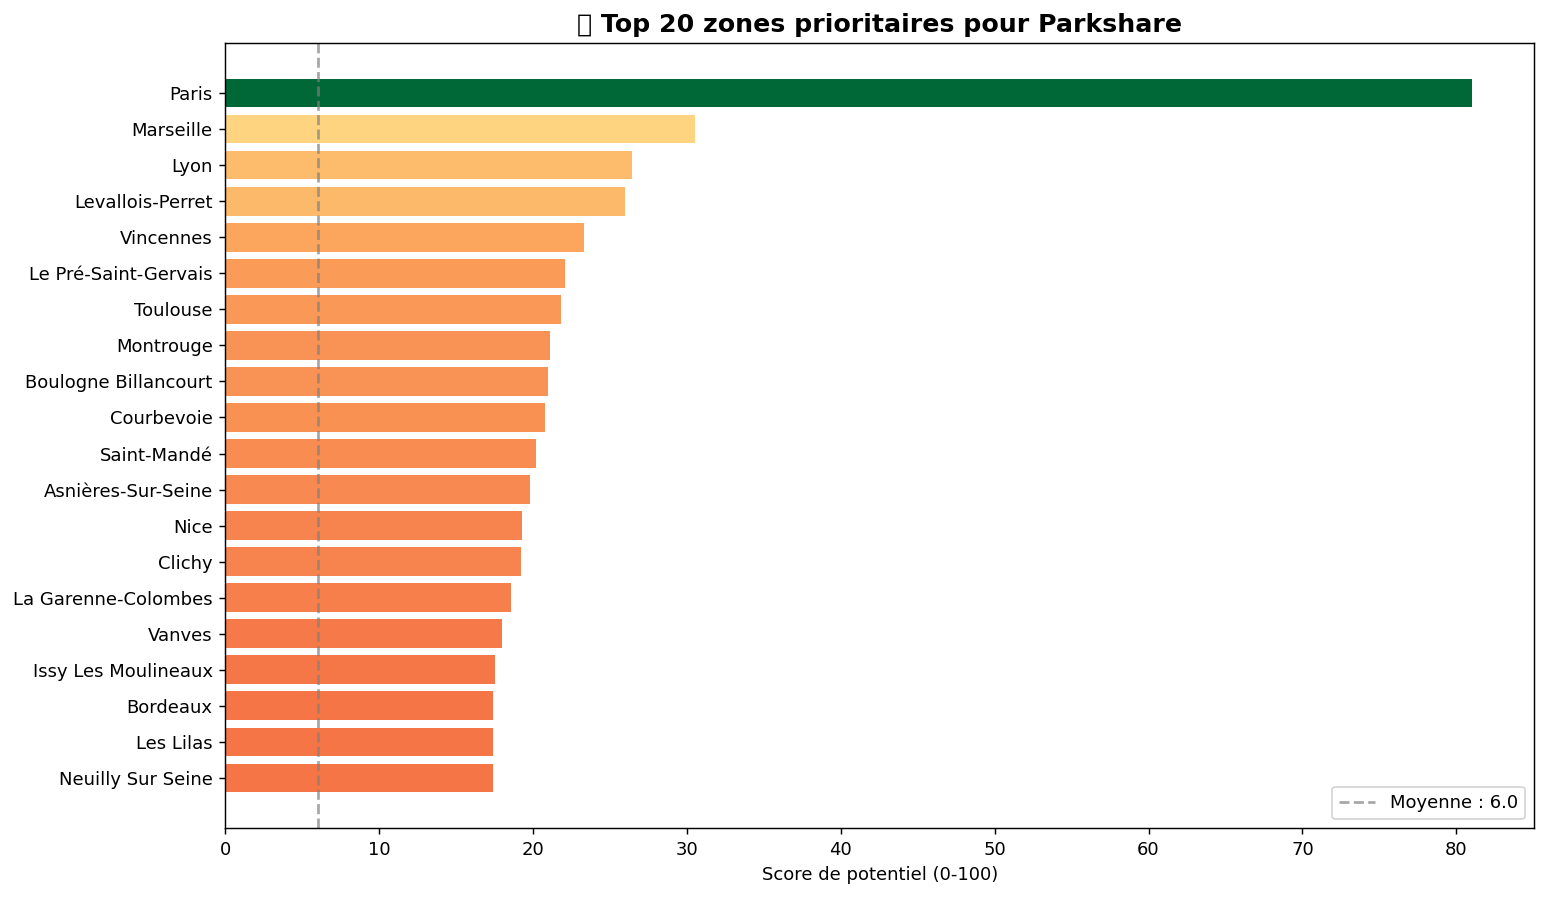

✅ Graphique 1 sauvegardé


In [15]:
fig, ax = plt.subplots(figsize=(12, 7))

top20_plot = top20.sort_values("score_potentiel")
colors = plt.cm.RdYlGn([x / top20_plot["score_potentiel"].max() for x in top20_plot["score_potentiel"]])

ax.barh(top20_plot["nom_commune"].str.title(), top20_plot["score_potentiel"], color=colors)
ax.axvline(
    x=df_score["score_potentiel"].mean(),
    color="gray", linestyle="--", alpha=0.7,
    label=f"Moyenne : {df_score['score_potentiel'].mean():.1f}"
)
ax.set_xlabel("Score de potentiel (0-100)")
ax.set_title("🏆 Top 20 zones prioritaires pour Parkshare", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(LIVRAISON_DIR / "graphique1_top20.png")
plt.show()
print("✅ Graphique 1 sauvegardé")

### Graphique 2 — Distribution des scores de potentiel

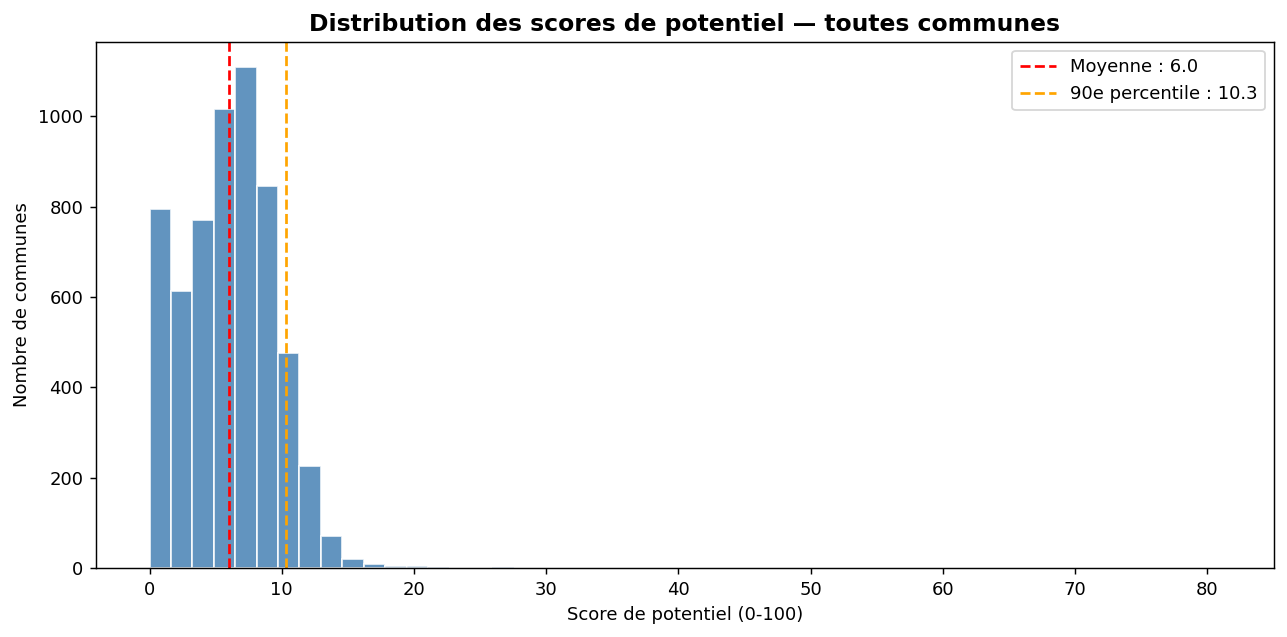

✅ Graphique 2 sauvegardé


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_score["score_potentiel"], bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(df_score["score_potentiel"].mean(), color="red", linestyle="--",
           label=f"Moyenne : {df_score['score_potentiel'].mean():.1f}")
ax.axvline(df_score["score_potentiel"].quantile(0.90), color="orange", linestyle="--",
           label=f"90e percentile : {df_score['score_potentiel'].quantile(0.90):.1f}")
ax.set_xlabel("Score de potentiel (0-100)")
ax.set_ylabel("Nombre de communes")
ax.set_title("Distribution des scores de potentiel — toutes communes", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(LIVRAISON_DIR / "graphique2_distribution_scores.png")
plt.show()
print("✅ Graphique 2 sauvegardé")

### Graphique 3 — Top 10 départements par nombre de copropriétés

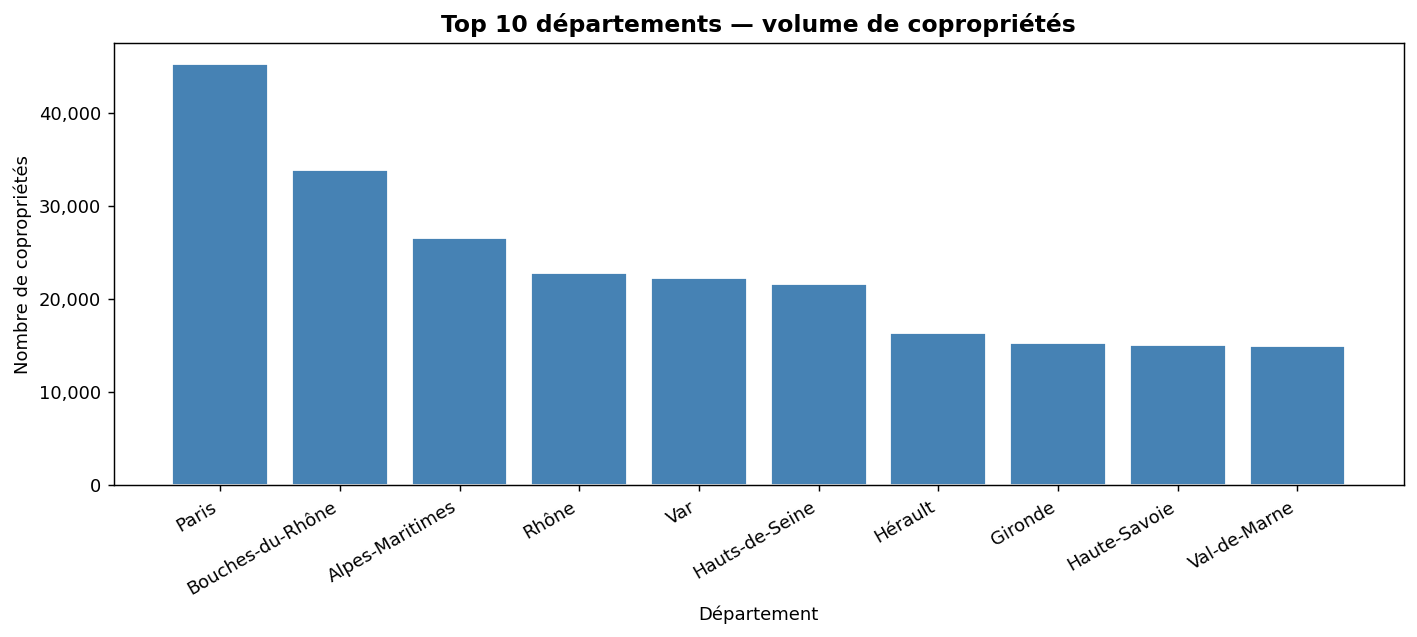

✅ Graphique 3 sauvegardé


In [17]:
top_dep = (
    df_score.groupby("departement")["nb_coproprietes"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_dep.index, top_dep.values, color="steelblue", edgecolor="white")
ax.set_xlabel("Département")
ax.set_ylabel("Nombre de copropriétés")
ax.set_title("Top 10 départements — volume de copropriétés", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(LIVRAISON_DIR / "graphique3_top_departements.png")
plt.show()
print("✅ Graphique 3 sauvegardé")

### Graphique 4 — Ratio parking vs Score de potentiel

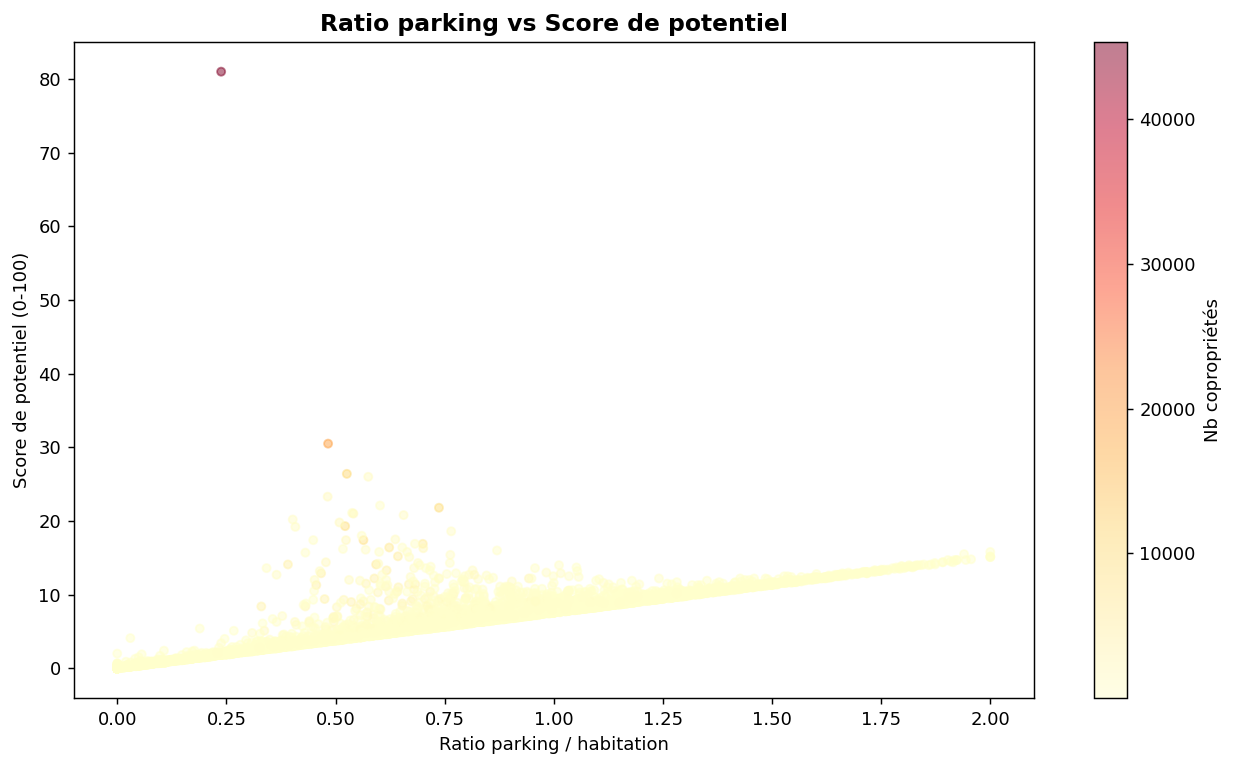

✅ Graphique 4 sauvegardé


In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    df_score["ratio_parking"],
    df_score["score_potentiel"],
    c=df_score["nb_coproprietes"],
    cmap="YlOrRd",
    alpha=0.5,
    s=20,
)
plt.colorbar(sc, ax=ax, label="Nb copropriétés")
ax.set_xlabel("Ratio parking / habitation")
ax.set_ylabel("Score de potentiel (0-100)")
ax.set_title("Ratio parking vs Score de potentiel", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(LIVRAISON_DIR / "graphique4_ratio_vs_score.png")
plt.show()
print("✅ Graphique 4 sauvegardé")

---
## Section 5 — Livraison

Export des fichiers finaux pour le Dev.

In [19]:
# Fichier 1 — Scoring complet de toutes les communes
df_score.to_csv(LIVRAISON_DIR / "scoring_communes.csv", index=False)

# Fichier 2 — Top 20 zones prioritaires
top20.to_csv(LIVRAISON_DIR / "top20_zones_prioritaires.csv", index=False)

# Récapitulatif
print("📦 Fichiers de livraison")
print("-" * 55)
for f in LIVRAISON_DIR.iterdir():
    print(f"  ✅ {f.name:<45} {f.stat().st_size / 1e6:.1f} Mo")

print(f"""
📊 Résumé du pipeline
  Copropriétés analysées : {len(df):,}
  Communes scorées       : {len(df_score):,}
  Score moyen            : {df_score['score_potentiel'].mean():.1f} / 100
  Meilleure commune      : {df_score.nlargest(1, 'score_potentiel')['nom_commune'].values[0]}
""")

📦 Fichiers de livraison
-------------------------------------------------------
  ✅ graphique2_distribution_scores.png            0.0 Mo
  ✅ graphique1_top20.png                          0.1 Mo
  ✅ scoring_communes.csv                          1.2 Mo
  ✅ graphique3_top_departements.png               0.1 Mo
  ✅ top20_zones_prioritaires.csv                  0.0 Mo
  ✅ graphique4_ratio_vs_score.png                 0.1 Mo

📊 Résumé du pipeline
  Copropriétés analysées : 609,663
  Communes scorées       : 5,968
  Score moyen            : 6.0 / 100
  Meilleure commune      : Paris

